# **MotorPH Products List 2025 – Distribution of Products by Category**

**Milestone 2 – MO-IT106 Data Analytics Fundamentals**

This notebook:
1. loads the two cleaned MotorPH files (product list and Q3 2025 sales),
2. edits the product list by adding Q3 sales figures and a category label,
3. builds a **matplotlib** chart showing the **distribution of products by category**, and
4. saves the outputs to the GitHub repository folder (`Milestone_2`) and to Google Drive.

In [1]:
# Connecting to Google Drive (Colab). Skipped automatically outside Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
# Import libraries
import os
import subprocess
import pandas as pd                 # data wrangling and manipulation
import matplotlib.pyplot as plt     # data visualization

pd.options.display.float_format = "{:,.2f}".format

In [3]:
# Paths and file names
DRIVE_DATA = "/content/drive/MyDrive/4thYR_Term1/MO-IT106 - Data Analytics Fundamentals/Week 07/DATA/"
DRIVE_OUT  = ("/content/drive/MyDrive/4thYR_Term1/MO-IT106 - Data Analytics Fundamentals/Week 07/"
              "[DRAFT] MO-IT106 | Milestone 2 | Dela Cruz, P.P./")

REPO_URL   = "https://github.com/padelacruz85/DAF2026.git"
GITHUB_RAW = "https://raw.githubusercontent.com/padelacruz85/DAF2026/main/Milestone_2/"
REPO_DIR   = "/content/DAF2026" if IN_COLAB else os.path.abspath(os.path.join(os.path.dirname(__file__), "..")) \
             if "__file__" in globals() else os.getcwd()

PRODUCTS = "[CLEANED_DATA]_MotorPH_Products_List_2025.csv"
SALES    = "[CLEANED_DATA]_MotorPH_Sales_Data-3rd_Quarter-Year_2025.csv"

# In Colab, clone the repository (if needed) so that outputs can be saved inside it.
if IN_COLAB and not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

# Repository output folder = Milestone_2 (created if it does not exist yet)
if os.path.basename(os.getcwd()) == "Milestone_2" and not IN_COLAB:
    REPO_OUT = os.getcwd()
else:
    REPO_OUT = os.path.join(REPO_DIR, "Milestone_2")
os.makedirs(REPO_OUT, exist_ok=True)

def locate(fname):
    """Google Drive first, then the repo folder, then the GitHub raw URL."""
    for p in [DRIVE_DATA + fname, os.path.join(REPO_OUT, fname), fname]:
        if os.path.exists(p):
            return p
    return GITHUB_RAW + fname.replace("[", "%5B").replace("]", "%5D").replace(" ", "%20")

# **1. LOAD THE DATA**

In [4]:
products = pd.read_csv(locate(PRODUCTS))
sales    = pd.read_csv(locate(SALES), parse_dates=["Date"])

print("Products:", products.shape, "| Sales:", sales.shape)
products.head()

Products: (50, 10) | Sales: (993, 9)


,Product ID Number,Product Name,Product Type,Engine Type,Cooling System,Engine Displacement (cc),Transmission,Manufacturing Year,Acquisition Year,Unit Price (PHP)
0,1,Honda CBR500R,Sport,Parallel Twin,Liquid-Cooled,471,6-Speed,2021,2023,"389,000.00"
1,2,Yamaha MT-15,Naked Bike,Single Cylinder,Liquid-Cooled,155,6-Speed,2022,2023,"178,000.00"
2,3,Kawasaki Ninja 400,Sport,Parallel Twin,Liquid-Cooled,399,6-Speed,2023,2024,"340,000.00"
3,4,Suzuki Raider R150 Fi,Underbone,Single Cylinder,Liquid-Cooled,150,6-Speed,2020,2021,"119,900.00"
4,5,Royal Enfield Classic 350,Classic,Single Cylinder,Air-Cooled,349,5-Speed,2022,2023,"250,000.00"


In [5]:
# Quick integrity checks before editing
assert products["Product ID Number"].is_unique, "Duplicate product IDs found"
assert products["Product Type"].notna().all(),  "Missing product categories found"
assert set(sales["Product ID Number"]) <= set(products["Product ID Number"]), "Sales reference unknown products"
print("Date range of sales:", sales["Date"].min().date(), "to", sales["Date"].max().date())

Date range of sales: 2025-06-01 to 2025-08-31


# **2. EDIT THE DATA**

- Rename `Product Type` to a clearer **Category** column (the original column is kept).
- Add each product's **Q3 2025 units sold, revenue and number of transactions** from the sales file.
- Build a **category summary** (number of products, share of the catalogue, units sold, revenue).

In [6]:
# Standardize the category text and add a clear Category column
products["Product Type"] = products["Product Type"].str.strip()
products["Category"]     = products["Product Type"]

# Q3 sales per product
sales_by_product = (sales.groupby("Product ID Number")
                         .agg(Units_Sold=("Quantity", "sum"),
                              Revenue_PHP=("Total Sales (PHP)", "sum"),
                              Transactions=("Transaction ID", "count"))
                         .rename(columns={"Units_Sold": "Q3 Units Sold",
                                          "Revenue_PHP": "Q3 Revenue (PHP)",
                                          "Transactions": "Q3 Transactions"})
                         .reset_index())

products_enriched = products.merge(sales_by_product, on="Product ID Number", how="left")
for c in ["Q3 Units Sold", "Q3 Revenue (PHP)", "Q3 Transactions"]:
    products_enriched[c] = products_enriched[c].fillna(0)
products_enriched[["Q3 Units Sold", "Q3 Transactions"]] = products_enriched[["Q3 Units Sold", "Q3 Transactions"]].astype(int)

products_enriched.head()

,Product ID Number,Product Name,Product Type,Engine Type,Cooling System,Engine Displacement (cc),Transmission,Manufacturing Year,Acquisition Year,Unit Price (PHP),Category,Q3 Units Sold,Q3 Revenue (PHP),Q3 Transactions
0,1,Honda CBR500R,Sport,Parallel Twin,Liquid-Cooled,471,6-Speed,2021,2023,"389,000.00",Sport,369,"143,541,000.00",23
1,2,Yamaha MT-15,Naked Bike,Single Cylinder,Liquid-Cooled,155,6-Speed,2022,2023,"178,000.00",Naked Bike,315,"56,070,000.00",17
2,3,Kawasaki Ninja 400,Sport,Parallel Twin,Liquid-Cooled,399,6-Speed,2023,2024,"340,000.00",Sport,255,"86,700,000.00",19
3,4,Suzuki Raider R150 Fi,Underbone,Single Cylinder,Liquid-Cooled,150,6-Speed,2020,2021,"119,900.00",Underbone,320,"38,368,000.00",26
4,5,Royal Enfield Classic 350,Classic,Single Cylinder,Air-Cooled,349,5-Speed,2022,2023,"250,000.00",Classic,458,"114,500,000.00",25


In [7]:
# Category summary (this is the data behind the chart)
category_summary = (products_enriched.groupby("Category")
                    .agg(Number_of_Products=("Product ID Number", "count"),
                         Q3_Units_Sold=("Q3 Units Sold", "sum"),
                         Q3_Revenue_PHP=("Q3 Revenue (PHP)", "sum"))
                    .rename(columns={"Number_of_Products": "Number of Products",
                                     "Q3_Units_Sold": "Q3 Units Sold",
                                     "Q3_Revenue_PHP": "Q3 Revenue (PHP)"})
                    .sort_values(["Number of Products", "Q3 Revenue (PHP)"], ascending=[False, False])
                    .reset_index())
category_summary["Share of Products (%)"] = (category_summary["Number of Products"]
                                             / category_summary["Number of Products"].sum() * 100).round(1)
category_summary

,Category,Number of Products,Q3 Units Sold,Q3 Revenue (PHP),Share of Products (%)
0,Scooter,12,4056,"747,176,900.00",24.00
1,Naked Bike,7,2150,"563,310,000.00",14.00
2,Cruiser,4,1427,"635,054,000.00",8.00
3,Adventure,4,1556,"392,804,700.00",8.00
4,Sport,4,1425,"372,471,000.00",8.00
5,Dual-Sport,3,1165,"306,517,800.00",6.00
6,Underbone,3,812,"90,240,800.00",6.00
7,Heritage,2,702,"553,140,000.00",4.00
8,Cafe Racer,2,578,"169,052,000.00",4.00
9,Commuter,2,881,"51,999,200.00",4.00


# **3. VISUALIZE: DISTRIBUTION OF PRODUCTS BY CATEGORY**

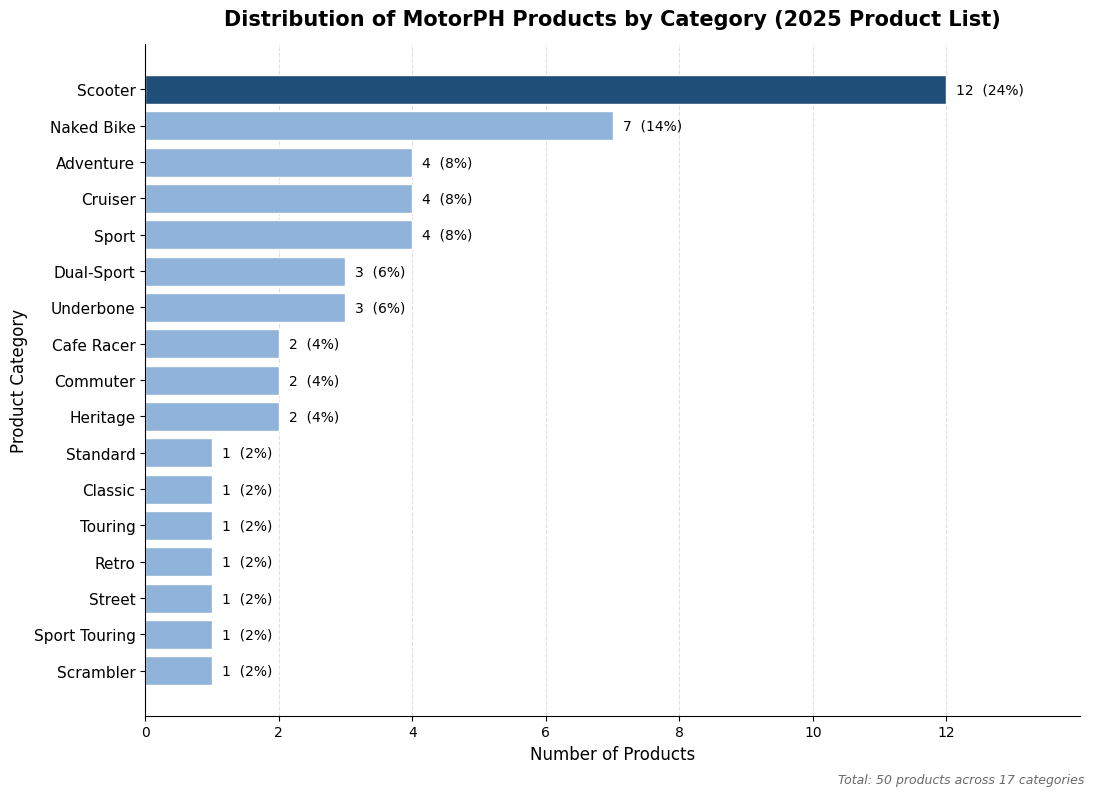

In [8]:
def plot_products_by_category(summary):
    """Horizontal bar chart: number of products per category, sorted from most to fewest."""
    data  = summary.sort_values("Number of Products", ascending=True)   # largest bar ends up on top
    total = data["Number of Products"].sum()
    top   = data["Number of Products"].max()
    colors = ["#1F4E79" if n == top else "#8FB3D9" for n in data["Number of Products"]]

    fig, ax = plt.subplots(figsize=(11, 8))
    bars = ax.barh(data["Category"], data["Number of Products"], color=colors, edgecolor="white")

    # Count and percentage label at the end of each bar
    for bar, n in zip(bars, data["Number of Products"]):
        ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
                f"{n}  ({n / total:.0%})", va="center", ha="left", fontsize=10)

    ax.set_title("Distribution of MotorPH Products by Category (2025 Product List)",
                 fontsize=15, fontweight="bold", pad=14)
    ax.set_xlabel("Number of Products", fontsize=12)
    ax.set_ylabel("Product Category", fontsize=12)
    ax.set_xlim(0, top + 2)
    ax.set_xticks(range(0, top + 2, 2))
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    fig.text(0.99, 0.01, f"Total: {total} products across {len(data)} categories",
             ha="right", va="bottom", fontsize=9, style="italic", color="dimgray")
    fig.tight_layout(rect=(0, 0.02, 1, 1))
    return fig

fig = plot_products_by_category(category_summary)
plt.show()

# **4. CHART EXPLANATION AND KEY INSIGHTS**

**Chart type: horizontal bar chart.** A bar chart is the right choice for comparing counts across *categorical* groups. With **17 categories** and some long names (e.g. "Sport Touring", "Dual-Sport"), horizontal bars keep every label fully readable, while sorting the bars from most to fewest products makes the ranking obvious at a glance. A pie chart would be unreadable with 17 slices, and a vertical chart would need rotated labels. The count and percentage share are printed at the end of each bar, and the largest category is highlighted in a darker colour.

**Key insights**
- **Scooters dominate the catalogue**: 12 of the 50 products (**24%**) are scooters, nearly twice as many as the next category.
- **Naked Bikes are second** with 7 products (14%). Together, the top two categories make up **38%** of the catalogue.
- **The top five categories** (Scooter, Naked Bike, Sport, Adventure, Cruiser) account for **31 of 50 products (62%)**.
- **The catalogue has a long tail**: 7 of the 17 categories (Classic, Retro, Sport Touring, Scrambler, Standard, Touring and Street) have **only one model each**, so MotorPH's offering in these niches is thin.
- **Business implication**: the product range is concentrated in practical, everyday-commuter and mainstream motorcycle segments, with only limited variety in niche and touring segments. Expanding those niches, or confirming they are intentionally small, is a decision for the assortment plan.

In [9]:
# Print the insights from the data itself so the text above can be verified
top2 = category_summary.head(2)
print(f"Categories: {len(category_summary)} | Products: {category_summary['Number of Products'].sum()}")
print(f"Largest category: {category_summary.iloc[0]['Category']} "
      f"({category_summary.iloc[0]['Number of Products']} products, {category_summary.iloc[0]['Share of Products (%)']}%)")
print(f"Top 2 share: {top2['Share of Products (%)'].sum():.1f}%")
print(f"Top 5 share: {category_summary.head(5)['Share of Products (%)'].sum():.1f}%")
print(f"Categories with a single product: {(category_summary['Number of Products'] == 1).sum()}")

Categories: 17 | Products: 50
Largest category: Scooter (12 products, 24.0%)
Top 2 share: 38.0%
Top 5 share: 62.0%
Categories with a single product: 7


# **5. SAVE THE OUTPUTS (REPOSITORY + GOOGLE DRIVE)**

In [10]:
OUTPUT_FILES = {}
CHART_NAME    = "[VISUALIZATION]_MotorPH_Products_by_Category_2025.png"
ENRICHED_NAME = "[EDITED_DATA]_MotorPH_Products_List_2025.csv"
SUMMARY_NAME  = "[SUMMARY]_MotorPH_Products_by_Category_2025.csv"

targets = [REPO_OUT]
if os.path.isdir(os.path.dirname(DRIVE_OUT.rstrip("/"))):       # Google Drive mounted / available
    os.makedirs(DRIVE_OUT, exist_ok=True)
    targets.append(DRIVE_OUT)
else:
    print("Google Drive path not found (not running in Colab) - saving to the repository folder only.")

for folder in targets:
    fig.savefig(os.path.join(folder, CHART_NAME), dpi=300, bbox_inches="tight")
    products_enriched.to_csv(os.path.join(folder, ENRICHED_NAME), index=False)
    category_summary.to_csv(os.path.join(folder, SUMMARY_NAME), index=False)
    print("Saved to:", folder)
    for f in (CHART_NAME, ENRICHED_NAME, SUMMARY_NAME):
        print("   ", f)

Google Drive path not found (not running in Colab) - saving to the repository folder only.


Saved to: /home/claude/DAF2026/Milestone_2
    [VISUALIZATION]_MotorPH_Products_by_Category_2025.png
    [EDITED_DATA]_MotorPH_Products_List_2025.csv
    [SUMMARY]_MotorPH_Products_by_Category_2025.csv


In [11]:
# OPTIONAL: copy this script / notebook to the Drive output folder and push the results to GitHub.
# Pushing needs a GitHub personal access token stored as a Colab secret named GITHUB_TOKEN
# (key icon in the left sidebar). Set PUSH_TO_GITHUB = True to enable.
PUSH_TO_GITHUB = False

if PUSH_TO_GITHUB and IN_COLAB:
    from google.colab import userdata
    token = userdata.get("GITHUB_TOKEN")
    remote = REPO_URL.replace("https://", f"https://{token}@")
    run = lambda *a: subprocess.run(a, cwd=REPO_DIR, check=True)
    run("git", "config", "user.name", "padelacruz85")
    run("git", "config", "user.email", "padelacruz85@users.noreply.github.com")
    run("git", "add", "Milestone_2")
    run("git", "commit", "-m", "Milestone 2: products by category visualization")
    run("git", "push", remote, "HEAD:main")